| Loss        | 解决问题      | 特点     |
| ----------- | --------- | ------ |
| Softmax     | 分类正确      | 基础     |
| Center Loss | 类内紧凑      | 增加中心约束 |
| ArcFace     | 类间分离+类内紧凑 | 目前主流   |


In [ ]:
from torch import nn
import torch
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 优化后的网络：更窄 + BatchNorm，计算更快、收敛更快
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 2)  # 2 维特征，用于可视化
        )
        self.fc2 = nn.Sequential(
            nn.Linear(2, 10)
        )

    def forward(self, x):
        x = x.reshape(-1, 28 * 28)
        feature = self.layers(x)
        cls_out = self.fc2(feature)
        return feature, cls_out


# CenterLoss：让同类特征向类中心聚拢，类内更紧凑
class CenterLoss(nn.Module):
    def __init__(self, num_classes=10, feat_dim=2):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim))

    def forward(self, x, labels):
        batch_size = x.size(0)
        # 计算特征与所有类中心的距离平方
        distmat = (torch.pow(x, 2).sum(dim=1, keepdim=True)
                   .expand(batch_size, self.centers.size(0))
                   + torch.pow(self.centers, 2).sum(dim=1, keepdim=True)
                   .expand(self.centers.size(0), batch_size).t())
        distmat.addmm_(1, -2, x, self.centers.t())
        # 只保留样本对应类别的距离
        classes = torch.arange(self.centers.size(0)).long().to(x.device)
        labels = labels.long().unsqueeze(1).expand(batch_size, self.centers.size(0))
        mask = labels.eq(classes.expand(batch_size, self.centers.size(0)))
        dist = distmat * mask.float()
        loss = dist.clamp(min=1e-12, max=1e12).sum() / batch_size
        return loss


# 可视化二维特征
def visualize(feature, labels, epoch):
    plt.ion()  # 动态绘图，开启绘画
    plt.show()
    c = ['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff', '#00ffff',
         '#990000', '#009900', '#000099', '#999900']
    plt.clf()  # 清屏
    for i in range(10):
        plt.plot(feature[labels == i, 0], feature[labels == i, 1], ".", c=c[i])
    plt.legend(["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], loc="upper right")
    plt.title("epoch=%d" % epoch)
    os.makedirs("images3", exist_ok=True)  # 确保保存目录存在
    plt.savefig("images3/epoch=%d.jpg" % epoch)
    plt.draw()
    plt.pause(0.001)


def trainer():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)
    # 网络
    net = Net().to(device)
    # 数据集
    train_data = datasets.MNIST(root='./data/MNIST', train=True, download=False,
                                transform=transforms.ToTensor())
    train_loader = DataLoader(train_data, batch_size=1000, shuffle=True)
    # 交叉熵损失：比 MSE + one-hot 收敛快很多
    loss_fun = nn.CrossEntropyLoss()
    # CenterLoss：让同类特征更紧凑
    center_loss = CenterLoss(num_classes=10, feat_dim=2).to(device)
    lam = 0.01  # center loss 权重
    # 优化器: 网络参数用 Adam
    opt = torch.optim.Adam(params=net.parameters())
    # 类中心参数用 SGD 单独更新（论文要求：中心不用带动量的优化器）
    opt_center = torch.optim.SGD(center_loss.parameters(), lr=0.5)
    for epoch in range(200):
        sum_loss = 0.
        sum_center = 0.
        count = 0
        correct = 0
        total = 0
        net.train()  # 训练
        feature_loader = []
        labels_loader = []
        for i, (img, label) in enumerate(train_loader):
            img, label = img.to(device), label.to(device)
            feature, cls_out = net(img)
            loss_cls = loss_fun(cls_out, label)      # 分类损失
            loss_ctr = center_loss(feature, label)   # 中心损失
            loss = loss_cls + lam * loss_ctr
            opt.zero_grad()  # 清空梯度
            opt_center.zero_grad()
            loss.backward()  # 根据loss，反向求导
            opt.step()  # 更新网络梯度
            opt_center.step()  # 更新类中心
            # 统计准确率
            preds = cls_out.argmax(dim=1)
            correct += (preds == label).sum().item()
            total += label.size(0)
            feature_loader.append(feature)
            labels_loader.append(label)
            sum_loss += loss.item()
            sum_center += loss_ctr.item()
            count += 1
        train_avg_loss = sum_loss / count
        center_avg_loss = sum_center / count
        acc = correct / total
        print(f"epoch = {epoch}, loss = {train_avg_loss:.4f}, center = {center_avg_loss:.4f}, acc = {acc:.4f}")
        features = torch.cat(feature_loader, dim=0)
        labels = torch.cat(labels_loader, dim=0)
        visualize(features.data.cpu().numpy(), labels.data.cpu().numpy(), epoch=epoch)


if __name__ == '__main__':
    trainer()

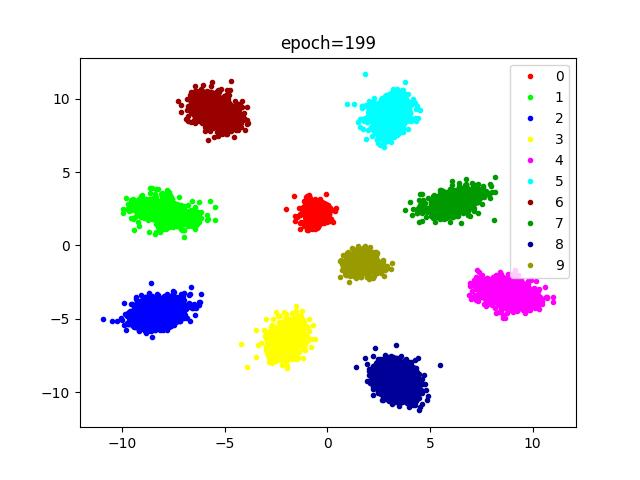

In [ ]:
# ============ ArcFace 损失函数 训练 MNIST ============
import math
import os
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 网络：只输出 2 维特征（用于可视化），不再需要 fc2 分类头
# ArcFace 内部的权重矩阵 W 就充当分类器
class ArcNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 2)  # 2 维特征，用于可视化
        )

    def forward(self, x):
        x = x.reshape(-1, 28 * 28)
        feature = self.layers(x)
        return feature


# ArcFaceLoss（加性角度间隔损失）：
#   1) 对特征 x 和权重 W 做 L2 归一化，把内积变成 cos(theta)
#   2) 对真实类别的角度加上 margin m：cos(theta + m) = cos(theta)cos(m) - sin(theta)sin(m)
#   3) 所有 logit 乘以缩放因子 s 后过 softmax 交叉熵
#   效果：类内更紧凑、类间角度被推开，比 softmax 更能学到判别性特征
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes=10, feat_dim=2, s=10.0, m=0.5):
        super().__init__()
        self.s = s          # 特征缩放因子（论文里通常取 64，这里取 10 足够）
        self.m = m          # 角度间隔（弧度），0.5 约等于 28.6°
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, feat_dim))
        nn.init.xavier_normal_(self.weight)

    def forward(self, feature, labels):
        # 1. L2 归一化特征和权重
        feature = F.normalize(feature, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)
        # 2. 余弦相似度 cos(theta_j) = W_j^T * x
        cos_theta = torch.matmul(feature, weight.t())  # (N, num_classes)
        # 关键：不能 clamp 到 ±1，否则 sin_theta 可能为 0，
        # 梯度里 cos(theta)/sin(theta) 会除以 0 -> NaN，导致后面图片全空白
        cos_theta = torch.clamp(cos_theta, -1.0 + 1e-7, 1.0 - 1e-7)
        # 3. sin(theta)
        sin_theta = torch.sqrt(1.0 - cos_theta ** 2)
        # 4. 对真实类别加角度间隔: cos(theta + m)
        cos_theta_m = cos_theta * math.cos(self.m) - sin_theta * math.sin(self.m)
        # 只替换真实类别的 logit，其它类别保持不变
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        output = torch.where(one_hot.bool(), cos_theta_m, cos_theta)
        # 5. 特征缩放 + softmax 交叉熵（ArcFace 本身已包含分类损失）
        output *= self.s
        return F.cross_entropy(output, labels)


# 可视化二维特征（保存到 images4，避免和上面 CenterLoss 的 images3 冲突）
def visualize(feature, labels, epoch):
    plt.ion()
    plt.show()
    c = ['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff', '#00ffff',
         '#990000', '#009900', '#000099', '#999900']
    plt.clf()
    for i in range(10):
        plt.plot(feature[labels == i, 0], feature[labels == i, 1], ".", c=c[i])
    plt.legend(["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], loc="upper right")
    plt.title("ArcFace epoch=%d" % epoch)
    os.makedirs("images4", exist_ok=True)
    plt.savefig("images4/epoch=%d.jpg" % epoch)
    plt.draw()
    plt.pause(0.001)


def trainer():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)
    net = ArcNet().to(device)
    # 数据集
    train_data = datasets.MNIST(root='./data/MNIST', train=True, download=False,
                                transform=transforms.ToTensor())
    train_loader = DataLoader(train_data, batch_size=1000, shuffle=True)
    # ArcFace 损失：一个损失同时负责"分类"和"拉开类间角度"
    arcface_loss = ArcFaceLoss(num_classes=10, feat_dim=2, s=10.0, m=0.5).to(device)
    # 优化器：网络参数 + ArcFace 权重一起用 Adam 更新（无需像 CenterLoss 那样单独 SGD）
    opt = torch.optim.Adam(params=list(net.parameters()) + list(arcface_loss.parameters()))
    for epoch in range(200):
        sum_loss = 0.
        count = 0
        correct = 0
        total = 0
        net.train()
        feature_loader = []
        labels_loader = []
        for i, (img, label) in enumerate(train_loader):
            img, label = img.to(device), label.to(device)
            feature = net(img)
            loss = arcface_loss(feature, label)   # ArcFace 损失（含分类）
            opt.zero_grad()
            loss.backward()
            opt.step()
            # 统计准确率：用归一化后的特征和权重做余弦相似度分类
            with torch.no_grad():
                w = F.normalize(arcface_loss.weight, p=2, dim=1)
                logits = torch.matmul(F.normalize(feature, p=2, dim=1), w.t())
                preds = logits.argmax(dim=1)
            correct += (preds == label).sum().item()
            total += label.size(0)
            feature_loader.append(feature)
            labels_loader.append(label)
            sum_loss += loss.item()
            count += 1
        train_avg_loss = sum_loss / count
        acc = correct / total
        print(f"epoch = {epoch}, loss = {train_avg_loss:.4f}, acc = {acc:.4f}")
        features = torch.cat(feature_loader, dim=0)
        labels = torch.cat(labels_loader, dim=0)
        visualize(features.data.cpu().numpy(), labels.data.cpu().numpy(), epoch=epoch)


if __name__ == '__main__':
    trainer()

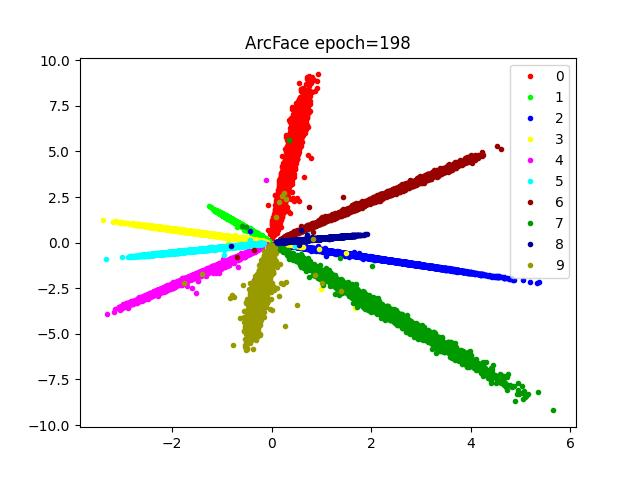

In [5]:
# ============ 装饰器示例 ============
import functools
import time

print("========== 1. 最简单的装饰器：函数执行计时 ==========")

def timer(func):
    """装饰器：打印函数的运行时间"""
    @functools.wraps(func)          # 保留原函数的 __name__ 和 __doc__
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"[{func.__name__}] 耗时 {end - start:.4f} 秒")
        return result
    return wrapper

@timer
def slow_add(a, b):
    """把两个数相加（模拟慢操作）"""
    time.sleep(0.1)
    return a + b

print("结果 =", slow_add(1, 2))
print("函数名 =", slow_add.__name__)   # 加了 wraps 后仍是 slow_add


print("\n========== 2. 带参数的装饰器（工厂）==========")

def repeat(times):
    """装饰器工厂：让函数重复执行 times 次"""
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            results = []
            for _ in range(times):
                results.append(func(*args, **kwargs))
            return results
        return wrapper
    return decorator

@repeat(3)
def say_hello(name):
    return f"你好, {name}!"

print(say_hello("张三"))


print("\n========== 3. 多个装饰器叠加（顺序：从下往上生效）==========")

def add_stars(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        print("******")
        return func(*args, **kwargs)
    return wrapper

def add_lines(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        print("------")
        return func(*args, **kwargs)
    return wrapper

@add_stars   # 外层：先打印星号
@add_lines   # 内层：先打印横线
def greet(name):
    return f"Hi, {name}"

print(greet("Bob"))


print("\n========== 4. 类装饰器 ==========")

class CountCalls:
    """记录函数被调用的次数"""
    def __init__(self, func):
        functools.update_wrapper(self, func)
        self.func = func
        self.count = 0

    def __call__(self, *args, **kwargs):
        self.count += 1
        print(f"第 {self.count} 次调用")
        return self.func(*args, **kwargs)

@CountCalls
def square(x):
    return x * x

print(square(3))
print(square(4))


print("\n========== 5. 实用例子：给训练函数加个计时/日志装饰器 ==========")

def log_epoch(func):
    """记录每个 epoch 的开始与结束"""
    @functools.wraps(func)
    def wrapper(epoch, *args, **kwargs):
        print(f"===== epoch {epoch} 开始 =====")
        t0 = time.time()
        result = func(epoch, *args, **kwargs)
        print(f"===== epoch {epoch} 结束，耗时 {time.time() - t0:.2f} 秒 =====")
        return result
    return wrapper

@log_epoch
def train_one_epoch(epoch):
    time.sleep(0.05)          # 模拟一次训练
    return {"epoch": epoch, "loss": 1.0 / (epoch + 1)}

for e in range(3):
    res = train_one_epoch(e)


========== 1. 最简单的装饰器：函数执行计时 ==========
[slow_add] 耗时 0.1012 秒
结果 = 3
函数名 = slow_add

========== 2. 带参数的装饰器（工厂）==========
['你好, 张三!', '你好, 张三!', '你好, 张三!']

========== 3. 多个装饰器叠加（顺序：从下往上生效）==========
******
------
Hi, Bob

========== 4. 类装饰器 ==========
第 1 次调用
9
第 2 次调用
16

========== 5. 实用例子：给训练函数加个计时/日志装饰器 ==========
===== epoch 0 开始 =====
===== epoch 0 结束，耗时 0.05 秒 =====
===== epoch 1 开始 =====
===== epoch 1 结束，耗时 0.05 秒 =====
===== epoch 2 开始 =====
===== epoch 2 结束，耗时 0.05 秒 =====


In [ ]:
import onnxruntime as ort 
import numpy as np 
import cv2
import time
radio = 1

# 计时装饰器：打印每个步骤的耗时
def decorator(func):
    def wrapper(*args,**kwargs):
        st_time = time.time()
        result = func(*args,**kwargs)
        end_time = time.time()
        print(f"{func.__name__}:cost_time",round(end_time-st_time,3),"s")
        return result
    return wrapper

# ============================================================
# 本机适配：模型路径 + 测试图片（改为绝对路径）
# ============================================================
# 模型：week12 导出的 YOLOv8n ONNX（COCO 80 类，输入 1x3x640x640，输出 1x84x8400）
ONNX_PATH = r"D:\project\step1\week12\yolov8n.onnx"
# 测试图片：官方 COCO 测试图 bus.jpg（公交车 + 行人 + 交通灯）
IMG_PATH  = r"D:\project\step1\week12\ultralytics-8.4.113\ultralytics\assets\bus.jpg"
# 结果保存路径
OUT_PATH  = r"D:\project\step1\week14\yolo_onnx_out.jpg"

class Yolov8_Infer:
    def __init__(self):
        self.session = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    @decorator
    def preprocess(self,img_data):
        h,w,_ =img_data.shape
        max_slide = max(h,w)
        img_zero = np.zeros((max_slide,max_slide,3),dtype = np.uint8)
        img_zero[:h,:w] = img_data 
        global radio 
        radio = max_slide/640
        img_data_re = cv2.resize(img_zero,(640,640))/255.0
        img_data_re = img_data_re.astype(np.float32)
        img_pre = np.expand_dims(np.transpose(img_data_re,(2,0,1)),axis=0)
        return img_pre
    @decorator
    def inference(self,input):
        return self.session.run(["output0"],{"images":input})
    @decorator
    def postprocess(self,out_results):
        filuter_bbox = []
        #(1, 84, 8400)
        #置信度过滤-nms去重
        out_result  =out_results[0]
        out_result = np.transpose(out_result,(0,2,1))[0]
        
        for bbox in out_result:
            class_scores = bbox[4:]              #
            class_id = np.argmax(class_scores)  #
            conf = class_scores[class_id]      #
            if conf > 0.25:
                cx,cy,w,h = bbox[:4]

                x = int((cx - w/2) * radio)
                y = int((cy - h/2) * radio)
                bw = int(w * radio)
                bh = int(h * radio)
                filuter_bbox.append([x, y, bw, bh, conf, class_id])

        # 没有检测到目标时直接返回空数组，避免后续索引报错
        if len(filuter_bbox) == 0:
            print("未检测到任何目标")
            return np.empty((0, 6))

        #nms去重
        np_filuter_bbox = np.array(filuter_bbox)
        bboxes = np_filuter_bbox[:,:4]
        confs = np_filuter_bbox[:,4]
        filter_idx = cv2.dnn.NMSBoxes(bboxes,confs,0.5,0.45)
        return  np_filuter_bbox[filter_idx]

    @decorator
    def forward(self,img):
        #获取归一化之后的图片
        img0 = self.preprocess(img)
        pred = self.inference(img0)
        filter_bbox = self.postprocess(pred)
        self.show_imgs(filter_bbox,img)
    @decorator
    def show_imgs(self,outlines,img):
        for line in outlines:
            x,y,w,h,conf,cls = line.astype(np.int32)
            cv2.rectangle(img,(x,y),(x+w,y+h),color=(0,0,255),thickness=2)
            cv2.putText(img,str(conf),(x,y+20),fontFace=cv2.FONT_HERSHEY_SIMPLEX,fontScale=1,thickness=1,color=(0,255,0))
        cv2.imwrite(OUT_PATH, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        print(f"结果已保存: {OUT_PATH}")



if __name__=="__main__":
    img_data = cv2.imread(IMG_PATH)
    if img_data is None:
        raise FileNotFoundError(f"图片不存在: {IMG_PATH}")
    img_rgb = cv2.cvtColor(img_data,cv2.COLOR_BGR2RGB)
    yolov8_infer = Yolov8_Infer()
    yolov8_infer.forward(img_rgb)